# Phase

Install dependencies

In [1]:
!pip install numpy matplotlib

Import dependencies

In [2]:
import numpy as np
import matplotlib.pyplot as plt 

## 1. Different ways of expressing signal frequency

Given an analog signal defined as $f(t) = sin(2 \pi f t)$ its <b>frequency</b> is provided by $f$ (expressed in Hz), whereas its <b>angular frequency</b> is provided by $2 \pi f$ (expressed in radians / cycle, often denoted by $\omega$).

Given a digital signal defined as $f(t) = sin(2 \pi f t)$, where $t$ represents sample number multiplied by $\frac{1}{f_{s}}$, its <b>normalised frequency</b> is provided by $\frac{f}{f_{s}}$ (expressed in cycles / sample), whereas its <b>normalised angular frequency</b> is provided by $2 \pi \frac{f}{f_{s}}$ (expressed in radians / sample, often denoted by $\omega$). Since $f$ and $f_{s}$ are constant, $\omega$ is also constant. Hence, calculating $nth$ sample value can be seen as multiplying $n$ by $\omega$ and then taking sine of the result.

In other words $f(t) = sin(2 \pi f t)$ can be rewritten as $f(n) = sin(2 \pi f t_{0} + \omega n)$ where $t_{0}$ is a constant, usually 0.

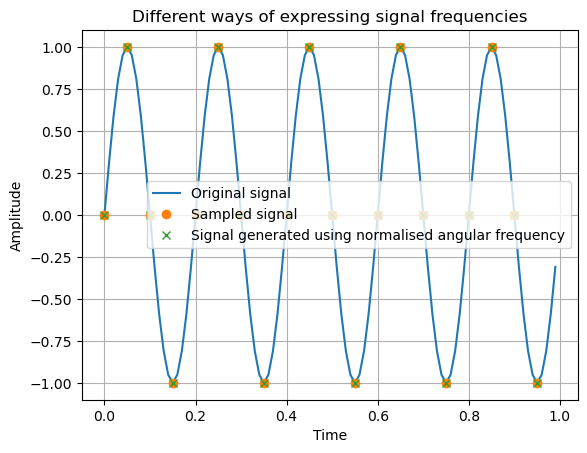

In [3]:
f = 5
fs = 100
w = 2 * np.pi * f / fs
t0 = 0
t = np.arange(0, 1, 1 / fs)
n = np.arange(0, len(t))
x = np.sin(2 * np.pi * f * t)
x_prime = np.sin(2 * np.pi * f * t0 + w * n)

plt.figure()
plt.grid()
plt.plot(t, x, label = "Original signal")
plt.plot(t, x, label = "Sampled signal", ls = " ", marker = "o", markevery = 5)
plt.plot(t, x_prime, label = "Signal generated using normalised angular frequency", ls = " ", marker = "x", markevery = 5)
plt.title("Different ways of expressing signal frequencies")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()

Because $t_{0} = 0$ and $\frac{n}{f_{s}} = t$, $f(n) = sin(2 \pi f t_{0} + \omega n)$ reduces to $f(t) = sin(2 \pi f t)$. So simple as that.

All these measures express basically the same value - signal frequency. Depending on a scenario, some are preferred over others, for instance digital filter design packages often use normalised angular frequency.

For more details, please see Richard G. Lyons, Understanding Digital Signal Processing (Third Edition), Prentice Hall, sections 3.13.4.2 & 3.13.4.3.

## 2. Frequency - phase duality

Often frequency offset error can be interpreted as phase offset error, or vice versa, phase offset error can be interpreted as frequency offset error. This is because exp / sin / cos is always calculated based on <b>sum</b> of frequency term and phase term. Therefore, from receiver perspective, these two terms are inseparable. In other words it can happen that $$e^{j 2 \pi f_{0} t + \phi_{0}} = e^{j 2 \pi f_{1} t + \phi_{1}}$$ at least at some values of $t$. For instance

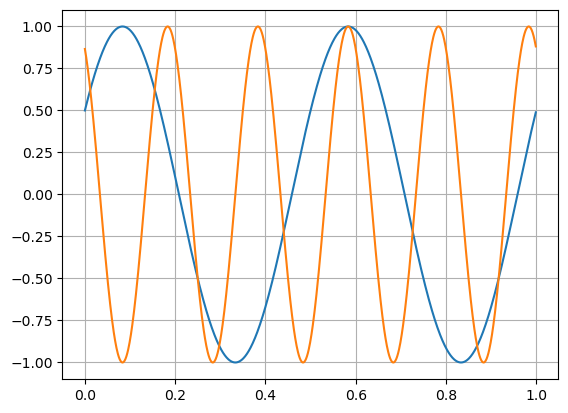

In [23]:
f0 = 2
phi0 = np.pi / 6
x0 = np.sin(2 * np.pi * f0 * t + phi0)

f1 = 5
phi1 = 2 * np.pi / 3
x1 = np.sin(2 * np.pi * f1 * t + phi1)

plt.figure()
plt.grid()
plt.plot(t, x0, label = r"$x(t) = sin(2 \pi f_{0} t + \phi_{0})$")
plt.plot(t, x1,label = r"$x(t) = sin(2 \pi f_{1} t + \phi_{1})$")

## 3. Linear phase

Let define a system that delays its output by value $\tau$, such that the output value at sample $\tau$ is equal to 0 and the output value at sample $\tau + 1$ is greater than zero. The output of such system for a signal with frequency $f_{0}$ will look as follows.

-1.48275480106659


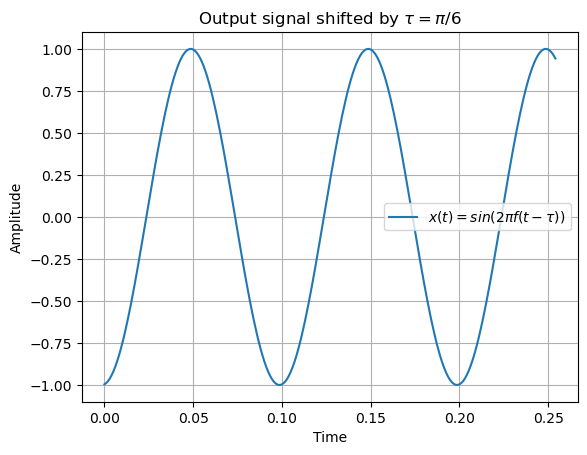

In [6]:
f0 = 10
t = np.arange(0, 1.0, 1 / 1000)
tau = np.pi / 6
x = np.sin(2 * np.pi * f0 * (t - tau))

phase = np.arcsin(x[0])
print(phase)

plt.grid()
plt.plot(t[:255], x[:255], label = r"$x(t) = sin(2 \pi f (t - \tau))$")
plt.title(r"Output signal shifted by $\tau = \pi / 6$")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()

Given that the output signal value at $t = 0$ is equal to -1, one can calculate $\tau$ as a function of $f_{0}$

$$sin(2 \pi f_{0} (t - \tau)) = -1$$

One can drop t since it is equal to 0.

$$sin(-2 \pi f_{0} \tau) = -1$$

After taking arcsin of both sides of equation

$$-2 \pi f_{0} \tau = -\frac{\pi}{2}$$

Next, after rearranging for $\tau$

$$\tau = \frac{1}{4 f_{0}}$$

Finally, after plugging in $\tau$ value to the original expression, we can find out actual phase value $\phi = \frac{\pi}{2}$.

$$sin(2 \pi f_{0}(t - \frac{1}{4 f_{0}})) = sin(2 \pi f_{0}t - \frac{\pi}{2}))$$

The same experiment can be repeated for $f_{1}$, which is equal to twice $f_{0}$

Signal value at t equal to 0 = -0.18


Text(0, 0.5, 'Amplitude')

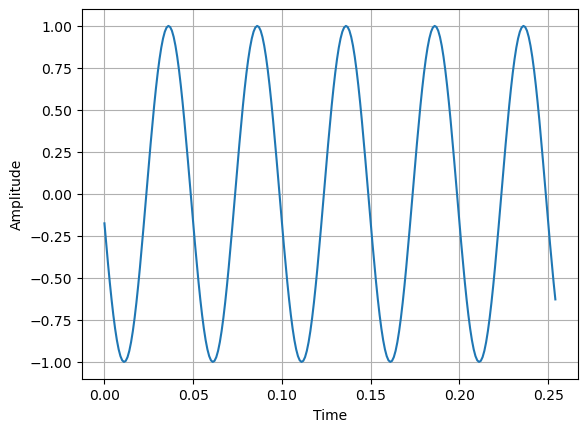

In [7]:
f1 = 2 * f0
x = np.sin(2 * np.pi * f1 * (t - tau))
print(f"Signal value at t equal to 0 = {np.round(x[0], 2)}")

plt.grid()
plt.plot(t[:255], x[:255])
plt.xlabel("Time")
plt.ylabel("Amplitude")

Now, the output signal value at $t = 0$ is equal to -0.18, in other words

$$sin(2 \pi f_{1} (t - \tau)) = -0.18$$

Following the same logic, one can find that in this case $\tau \approx -\frac{2}{7 f_{1}}$ and hence $\phi \approx \frac{4 \pi}{7}$

The same experiments can be performed for each and every frequency. Then one can plot the calculated phase as a function of frequency. If the diagram presents a straight line, then the phase of such system is linear.

All copyright reserved @2025 Ericsson